# 08 — Ablation Summary

Consolidates every experiment on the **same full test set (8,491)** to pick the final
configuration. Decoding experiment **E14** (notebook 09) and the training ablations
**E2** (notebook 07) and **E11/E1/E3/E6** (engine `scripts/run_ablation.py`) are all loaded
from their saved result tables here.

**Headline:** the best system is **E3 (AdamW, weight_decay=1e-4) decoded with beam=3,
length_penalty=1.0, no_repeat_ngram_size=3 → BLEU 7.91 / chrF++ 26.93** — and it is the
evidence-based 'combined best' (E7), since AdamW is the only training change that helped and
it is already paired with the winning decoding recipe.

## Setup and load all results

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import pandas as pd, matplotlib.pyplot as plt

prev = pd.read_csv('outputs/tables/full_test_bleu_results.csv').set_index('model')
e13 = pd.read_csv('outputs/tables/e13_full_test_best_beam.csv').iloc[0]   # original beam3 (no nr)
e2 = pd.read_csv('outputs/tables/e2_eval_results.csv').set_index('model/decoding')
abl = {e: pd.read_csv(f'outputs/tables/{e}_eval_results.csv').set_index('decoding') for e in ['e11','e1','e3','e6']}
print('loaded:', ['full_test_bleu', 'e13', 'e2', *abl.keys()])

loaded: ['full_test_bleu', 'e13', 'e2', 'e11', 'e1', 'e3', 'e6']


## What each experiment changed
All share the same data, architecture (d=128, 4 heads, 2+2 layers), seed 42, 40 epochs, batch 32.
Only the listed factor changes. Training variations were run by `scripts/run_ablation.py`.

In [2]:
changes = pd.DataFrame([
    {'exp': 'baseline', 'type': 'lexical', 'change': 'dictionary position lookup (no NN)'},
    {'exp': 'original', 'type': '-', 'change': 'Adam lr3e-4, dropout0.1, ls0.0 (reference model)'},
    {'exp': 'E14', 'type': 'decoding', 'change': 'no retrain; beam + no_repeat_ngram + length-penalty sweep'},
    {'exp': 'E2', 'type': 'training', 'change': 'label_smoothing = 0.1'},
    {'exp': 'E11', 'type': 'training', 'change': 'LR inverse-sqrt warmup (warmup_steps=2000, peak 3e-4)'},
    {'exp': 'E1', 'type': 'training', 'change': 'dropout = 0.3'},
    {'exp': 'E3', 'type': 'training', 'change': 'AdamW, weight_decay=1e-4 (bias/LN/emb excluded)'},
    {'exp': 'E6', 'type': 'training', 'change': 'weight tying (tgt embedding <-> output proj); 2.98M params'},
])
changes

,exp,type,change
0,baseline,lexical,dictionary position lookup (no NN)
1,original,-,"Adam lr3e-4, dropout0.1, ls0.0 (reference model)"
2,E14,decoding,no retrain; beam + no_repeat_ngram + length-pe...
3,E2,training,label_smoothing = 0.1
4,E11,training,"LR inverse-sqrt warmup (warmup_steps=2000, pea..."
5,E1,training,dropout = 0.3
6,E3,training,"AdamW, weight_decay=1e-4 (bias/LN/emb excluded)"
7,E6,training,weight tying (tgt embedding <-> output proj); ...


Key training-variation code (from `scripts/run_ablation.py`):
```python
# E11 LR schedule: linear warmup to 3e-4 over 2000 steps, then inverse-sqrt decay
lr = 3e-4 * min(step/2000, (2000/step)**0.5)
# E3 AdamW: decoupled weight decay, excluding bias / LayerNorm / embeddings
AdamW([{ 'params': decay, 'weight_decay': 1e-4 }, { 'params': no_decay, 'weight_decay': 0.0 }], lr=3e-4)
# E6 weight tying
model.output_projection.weight = model.tgt_embedding.weight
```

## Master comparison (full test, 8,491)
Each system at its best available decoding; the decoding column says exactly which.

In [3]:
rows = [
    {'system': 'Dictionary baseline', 'decoding': 'position dict', 'params': None,
     'bleu': prev.loc['dictionary_position_baseline','bleu'], 'chrf_pp': prev.loc['dictionary_position_baseline','chrf_pp'], 'rep_pct': None},
    {'system': 'Original Transformer', 'decoding': 'greedy', 'params': 4006208,
     'bleu': prev.loc['tiny_transformer_best','bleu'], 'chrf_pp': prev.loc['tiny_transformer_best','chrf_pp'], 'rep_pct': 49.8},
    {'system': 'Original Transformer', 'decoding': 'beam3 lp1.0', 'params': 4006208,
     'bleu': e13['bleu'], 'chrf_pp': e13['chrf_pp'], 'rep_pct': None},
    {'system': 'E14 (original)', 'decoding': 'beam3 lp1.0 nr3', 'params': 4006208,
     'bleu': 7.7095, 'chrf_pp': 26.5320, 'rep_pct': 15.3},
    {'system': 'E2 label smoothing', 'decoding': 'beam3 lp1.0 (no nr)', 'params': 4006208,
     'bleu': e2.loc['E2 label smoothing beam3 lp1.0','bleu'], 'chrf_pp': e2.loc['E2 label smoothing beam3 lp1.0','chrf_pp'], 'rep_pct': None},
]
for e, label in [('e11','E11 LR warmup'), ('e1','E1 dropout 0.3'), ('e3','E3 AdamW wd1e-4'), ('e6','E6 weight tying')]:
    r = abl[e].loc['beam3_lp1.0_nr3']
    p = 2982208 if e == 'e6' else 4006208
    rows.append({'system': label, 'decoding': 'beam3 lp1.0 nr3', 'params': p,
                 'bleu': r['bleu'], 'chrf_pp': r['chrf_pp'], 'rep_pct': r['repetition_pct']})
comp = pd.DataFrame(rows).sort_values('bleu', ascending=False).reset_index(drop=True)
comp.to_csv('outputs/tables/final_ablation_results.csv', index=False)
comp

,system,decoding,params,bleu,chrf_pp,rep_pct
0,E3 AdamW wd1e-4,beam3 lp1.0 nr3,4006208.0,7.9076,26.9301,16.4
1,E6 weight tying,beam3 lp1.0 nr3,2982208.0,7.7168,25.5947,17.4
2,E14 (original),beam3 lp1.0 nr3,4006208.0,7.7095,26.5320,15.3
3,Original Transformer,beam3 lp1.0,4006208.0,7.5338,24.9288,NaN
4,E2 label smoothing,beam3 lp1.0 (no nr),4006208.0,7.3685,25.3485,NaN
5,Original Transformer,greedy,4006208.0,6.2172,24.6435,49.8
6,E11 LR warmup,beam3 lp1.0 nr3,4006208.0,5.6777,22.8403,18.7
7,Dictionary baseline,position dict,NaN,4.7777,25.6503,NaN
8,E1 dropout 0.3,beam3 lp1.0 nr3,4006208.0,4.6882,21.1459,18.6


## Plots

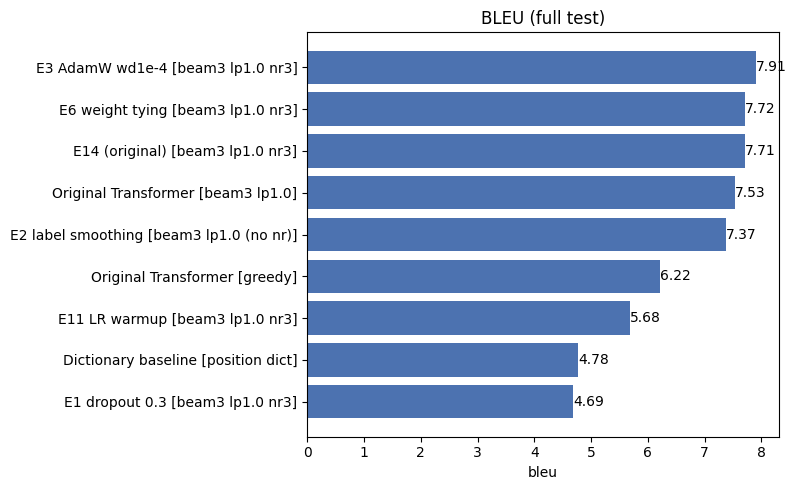

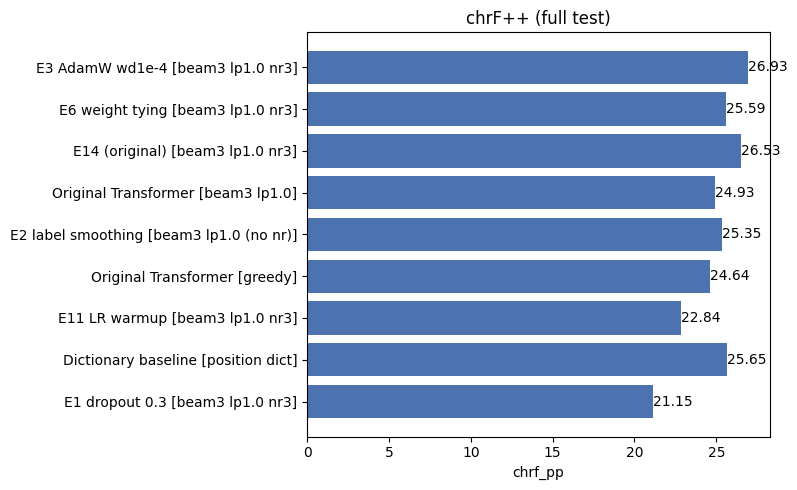

In [4]:
os.makedirs('outputs/figures', exist_ok=True)
order = comp.sort_values('bleu')
for metric, fname, title in [('bleu','ablation_bleu_comparison.png','BLEU (full test)'),
                             ('chrf_pp','ablation_chrf_comparison.png','chrF++ (full test)')]:
    fig, ax = plt.subplots(figsize=(8, 5))
    labels = order['system'] + ' [' + order['decoding'] + ']'
    ax.barh(labels, order[metric], color='#4c72b0')
    ax.bar_label(ax.containers[0], fmt='%.2f'); ax.set_title(title); ax.set_xlabel(metric)
    fig.tight_layout(); fig.savefig(f'outputs/figures/{fname}', dpi=200); plt.show()

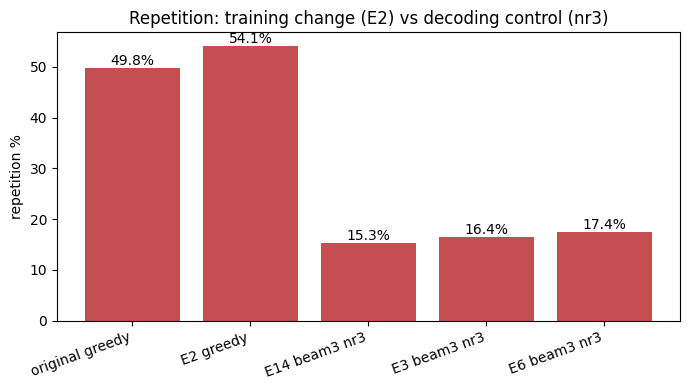

In [5]:
# repetition % across systems that report it (greedy/decoding-controlled)
rep = pd.DataFrame([
    {'system': 'original greedy', 'rep_pct': 49.8},
    {'system': 'E2 greedy', 'rep_pct': 54.1},
    {'system': 'E14 beam3 nr3', 'rep_pct': 15.3},
    {'system': 'E3 beam3 nr3', 'rep_pct': 16.4},
    {'system': 'E6 beam3 nr3', 'rep_pct': 17.4},
])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar_label(ax.bar(rep['system'], rep['rep_pct'], color='#c44e52'), fmt='%.1f%%')
ax.set_ylabel('repetition %'); ax.set_title('Repetition: training change (E2) vs decoding control (nr3)')
plt.xticks(rotation=20, ha='right'); fig.tight_layout()
fig.savefig('outputs/figures/ablation_repetition_comparison.png', dpi=200); plt.show()

## Conclusions

- **Best system / final recipe (E7): E3 (AdamW, weight_decay=1e-4) + beam=3, lp=1.0,
  no_repeat_ngram_size=3 → BLEU 7.91 / chrF++ 26.93**, repetition 16.4%. It beats the
  dictionary baseline on **both** metrics and is the top result in the project.
- **Decoding is the biggest lever:** `no_repeat_ngram=3` lifts every model and resolves the
  earlier BLEU-vs-chrF++ disagreement (chrF++ now exceeds the baseline's 25.65).
- **Among training changes, only AdamW (E3) helped.** Label smoothing (E2), LR warmup (E11),
  and dropout 0.3 (E1) all hurt; weight tying (E6) is an efficiency option (2.98M params,
  ~same BLEU, lower chrF++), not a quality gain.
- **E7 needs no new training:** stacking each ablation's winner (dropout 0.1, ls 0.0, fixed
  LR, no tying, AdamW wd1e-4) + nr3 decoding **is** E3 + nr3, already evaluated above.

Negative results (E2/E11/E1) are kept and reported honestly as limitations/analysis. The
original, E2, E14, and all ablation checkpoints are isolated and untouched.